Libraries imported successfully.
 Model loaded successfully from:
  ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_GradientBoosting_model.pkl

 Training data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_train_data.parquet (shape: (56, 7))
 Test data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_test_data.parquet (shape: (11, 7))
 Predictions made for both training and test sets.
  - Training predictions shape: (56,)
  - Test predictions shape: (11,)
 Predictions made for both training and test sets.
  - Training predictions shape: (56,)
  - Test predictions shape: (11,)

[TRAIN]
  Accuracy          : 0.8750
  Balanced Accuracy : 0.8714
  F1 (macro)        : 0.8679

[TEST]
  Accuracy          : 0.8182
  Balanced Accuracy : 0.8036
  F1 (macro)        : 0.8036

╔══════════════════════╦═════════════╦═════════════╗
║       Metric         ║  Train Set  ║   Test Set  ║
╠══════════════════════╬════════

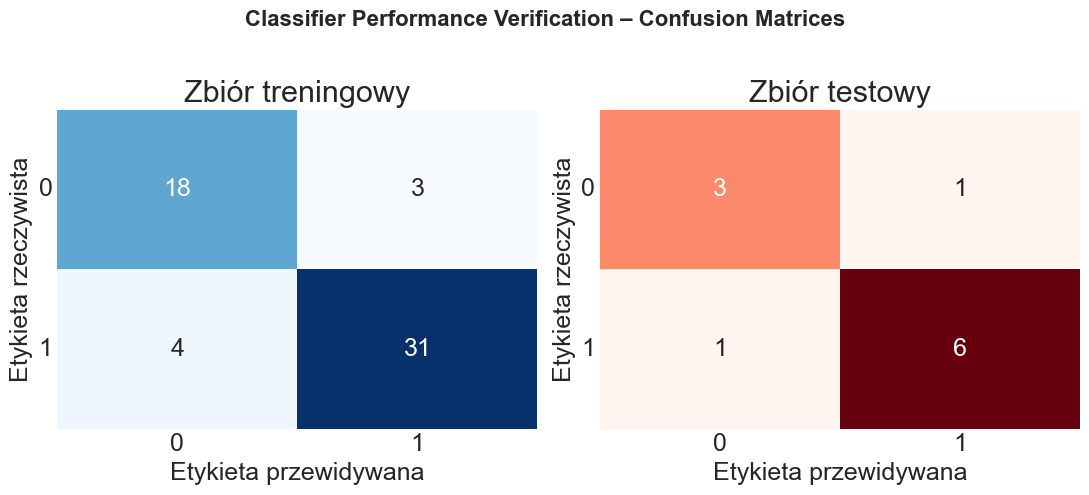

 Figure saved as 'classifier_confusion_matrices.svg'


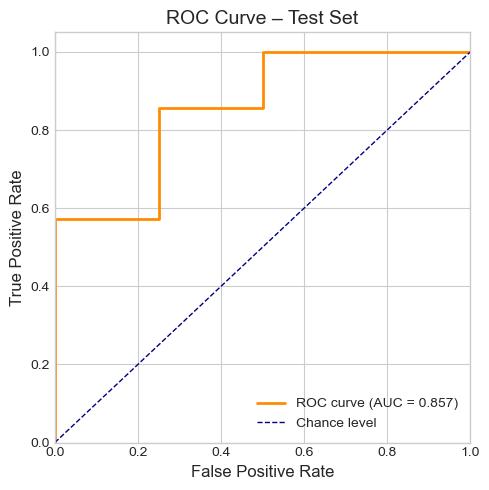

 Figure saved as 'classifier_ROC_test.svg'


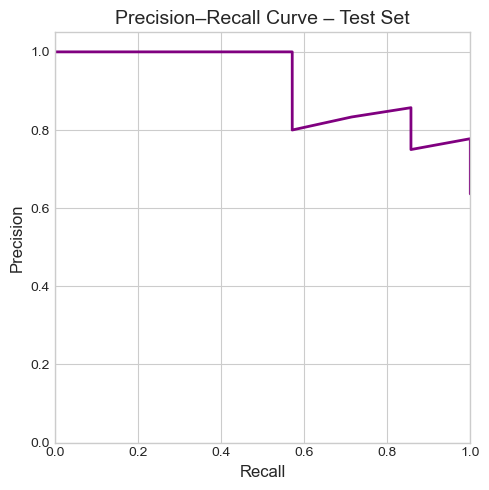

 Figure saved as 'classifier_PR_test.svg'


In [36]:
# # QSPR Model Verification and Visualization
# 
# This notebook loads a previously trained model and its corresponding training/test data to:
# 1.  Verify the model's performance by recalculating key metrics.
# 2.  Generate a publication-quality scatter plot of observed vs. predicted values.
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("Libraries imported successfully.")

# ===================================================================
# CONFIGURATION: Specify file paths
# ===================================================================
model_path = './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_GradientBoosting_model.pkl'
train_data_path = './Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_train_data.parquet'
test_data_path = './Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_test_data.parquet'

# Load the model
model = joblib.load(model_path)
print(f" Model loaded successfully from:\n  {model_path}\n")

# Load the datasets
train_df = pd.read_parquet(train_data_path)
test_df = pd.read_parquet(test_data_path)
print(f" Training data loaded successfully from:\n  {train_data_path} (shape: {train_df.shape})")
print(f" Test data loaded successfully from:\n  {test_data_path} (shape: {test_df.shape})")
# ## Prepare Data and Make Predictions

# ===================================================================
# DATA PREPARATION AND PREDICTION
# ===================================================================
# Separate features (X) and target (y)
TARGET_COLUMN = 'epox_cla'

X_train = train_df.drop(columns=[TARGET_COLUMN])
X_train = X_train[list(train_df.iloc[:, :-1].columns)]
y_train = train_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN])
X_test = X_test[list(train_df.iloc[:, :-1].columns)]
y_test = test_df[TARGET_COLUMN]

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# Predicted probabilities (assumes binary classification and predict_proba support)
if hasattr(model, "predict_proba") and len(np.unique(y_train)) == 2:
    y_proba_train = model.predict_proba(X_train)[:, 1]
    y_proba_test = model.predict_proba(X_test)[:, 1]
else:
    y_proba_train = None
    y_proba_test = None

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# ===================================================================
# PERFORMANCE VERIFICATION
# ===================================================================
def summarize_performance(y_true, y_pred, split_name=""):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"\n[{split_name}]")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Balanced Accuracy : {bal_acc:.4f}")
    print(f"  F1 (macro)        : {f1_macro:.4f}")
    return acc, bal_acc, f1_macro

train_acc, train_bal_acc, train_f1 = summarize_performance(y_train, y_pred_train, "TRAIN")
test_acc, test_bal_acc, test_f1 = summarize_performance(y_test, y_pred_test, "TEST")

print("\n╔══════════════════════╦═════════════╦═════════════╗")
print("║       Metric         ║  Train Set  ║   Test Set  ║")
print("╠══════════════════════╬═════════════╬═════════════╣")
print(f"║ Accuracy             ║  {train_acc:9.4f}  ║  {test_acc:9.4f}  ║")
print(f"║ Balanced Accuracy    ║  {train_bal_acc:9.4f}  ║  {test_bal_acc:9.4f}  ║")
print(f"║ F1 (macro)           ║  {train_f1:9.4f}  ║  {test_f1:9.4f}  ║")
print("╚══════════════════════╩═════════════╩═════════════╝")

# Optional: detailed text report for test set
print("\nClassification report (TEST):")
print(classification_report(y_test, y_pred_test, digits=3))

# ===================================================================
# CONFUSION MATRICES (TRAIN & TEST)
# ===================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(11, 5.0))
fig.suptitle('Classifier Performance Verification – Confusion Matrices', fontsize=16, fontweight='bold')

# Class labels (sorted for consistent ordering)
labels = np.sort(train_df[TARGET_COLUMN].unique())

# --- Training Confusion Matrix ---
cm_train = confusion_matrix(y_train, y_pred_train, labels=labels)
sns.heatmap(
    cm_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    annot_kws={"size": 18}
)
axes[0].set_title('Zbiór treningowy', fontsize=22)
axes[0].set_xlabel('Etykieta przewidywana', fontsize=18)
axes[0].set_ylabel('Etykieta rzeczywista', fontsize=18)
axes[0].set_xticklabels(labels, fontsize=18)
axes[0].set_yticklabels(labels, fontsize=18, rotation=0)

# --- Test Confusion Matrix ---
cm_test = confusion_matrix(y_test, y_pred_test, labels=labels)
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Reds',
    cbar=False,
    ax=axes[1],
    annot_kws={"size": 18}
)
axes[1].set_title('Zbiór testowy', fontsize=22)
axes[1].set_xlabel('Etykieta przewidywana', fontsize=18)
axes[1].set_ylabel('Etykieta rzeczywista', fontsize=18)
axes[1].set_xticklabels(labels, fontsize=18)
axes[1].set_yticklabels(labels, fontsize=18, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# Save confusion-matrix figure
plt.savefig('classifier_confusion_matrices_DOCTORATE.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

print(" Figure saved as 'classifier_confusion_matrices.svg'")

# ===================================================================
# ROC AND PRECISION–RECALL CURVES (TEST, BINARY ONLY)
# ===================================================================
if y_proba_test is not None:
    # --- ROC curve ---
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5.0, 5.0))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Chance level')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve – Test Set', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('classifier_ROC_test.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.show()

    print(" Figure saved as 'classifier_ROC_test.svg'")

    # --- Precision–Recall curve ---
    precision, recall, _ = precision_recall_curve(y_test, y_proba_test)

    plt.figure(figsize=(5.0, 5.0))
    plt.plot(recall, precision, color='purple', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision–Recall Curve – Test Set', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('classifier_PR_test.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.show()

    print(" Figure saved as 'classifier_PR_test.svg'")
else:
    print("\n ROC/PR curves were skipped: model does not support predict_proba or problem is not binary.")

In [37]:
model[2]

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",1
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [38]:
## Validation set

import sys
import pandas as pd
import numpy as np
import pickle
import warnings
from pathlib import Path
from datetime import datetime

# Add module path for imports
module_path = Path('.').parent / 'module'  # Adjust if needed
if module_path.exists():
    sys.path.insert(0, str(module_path))
    print(f" Module path added: {module_path}")
else:
    print(f" Module path not found: {module_path}")
    print(f"  Current directory: {Path('.').resolve()}")
    print(f"  Please ensure calculate_descriptors.py is in a 'module' subdirectory")

warnings.filterwarnings('ignore')

# Import from your QSPR module
try:
    from calculate_descriptors import prepare_data
    print(" Successfully imported from calculate_descriptors.py")
except ImportError as e:
    print(f" Error importing from models_creation.py: {e}")
    raise

print("\n All imports successful")

 Module path added: module
 Successfully imported from calculate_descriptors.py

 All imports successful


In [39]:
CONFIG = {
    # Data file
    'data': './Data/model_cla_val.xlsx',
    'target_col': 'epox_cla',
    'name': 'validation_set',
    'mode': 'validation',
    'output_dir': './Data/'
}

In [40]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/model_cla_val.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: False
 Morgan FP: False
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: False

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_validation_set_.parquet
Shape: (9, 159)
Returning: full descriptor set

 Data loaded and ALL descriptors calculated
  Total samples: 9

In [41]:
X_train.columns

Index(['Sterimol_Beta_R2_B5', 'Sterimol_Alpha_R1_L',
       'CircuS_r1-3_O1[C@@H](C)C1', 'CircuS_r1-3_ccc',
       'CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C',
       'CircuS_r1-3_[C@@H]1([C@H](C)O1)C'],
      dtype='object')

In [42]:
data[list(X_train.columns)]

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C
0,2.067224,3.616949,2,9,1,1
1,2.035567,3.609572,1,0,0,0
2,2.067571,3.614989,2,9,1,1
3,2.059260,3.612168,2,10,1,1
4,2.052779,3.612700,2,5,1,1
5,2.066421,7.993483,1,9,0,0
6,2.066272,3.614391,2,5,0,1
7,2.067233,3.616889,2,9,1,1
8,2.067644,3.617406,2,8,1,1


In [43]:
y_pred_val = model.predict(data[list(X_train.columns)])

In [44]:
y_pred_val

array([1, 1, 1, 1, 1, 0, 0, 1, 1])

In [45]:
y_pred_val[0]

np.int64(1)

In [46]:
data['epox_cla']

0    1
1    1
2    1
3    1
4    1
5    0
6    0
7    1
8    1
Name: epox_cla, dtype: int64

In [47]:
val_acc, val_bal_acc, val_f1 = summarize_performance(data['epox_cla'], y_pred_val, "VAL")

print("╔════════════════════════════╦═══════════════════════════╗")
print("║          Metric            ║      Validation Set       ║")
print("╠════════════════════════════╬═══════════════════════════╣")
print(f"║ Accuracy                   ║   {val_acc:.4f}                  ║")
print(f"║ Balanced Accuracy          ║   {val_bal_acc:.4f}                  ║")
print(f"║ F1 (macro)                 ║   {val_f1:.4f}                  ║")
print("╚════════════════════════════╩═══════════════════════════╝")


[VAL]
  Accuracy          : 1.0000
  Balanced Accuracy : 1.0000
  F1 (macro)        : 1.0000
╔════════════════════════════╦═══════════════════════════╗
║          Metric            ║      Validation Set       ║
╠════════════════════════════╬═══════════════════════════╣
║ Accuracy                   ║   1.0000                  ║
║ Balanced Accuracy          ║   1.0000                  ║
║ F1 (macro)                 ║   1.0000                  ║
╚════════════════════════════╩═══════════════════════════╝


In [48]:
for x in range(len(y_pred_val)):

    print("Observed ee: " + str(data['epox_cla'][x]) + '   ' + "Predicted ee: " +str(y_pred_val[x]))

Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1


In [49]:
validation_data = './Data/model_cla_val.xlsx'


# Load the datasets
val_df = pd.read_excel(validation_data)
val_df.head(1)

,Reaction ID,Reaction: Links to Reaxys,Reactant,Product,Bin,SMILES,SMILES__,Reaction,Number of Reaction Steps,Time (Reaction Details) [h],...,Reagent,SMILES ligand,SMILES mieszanina reakcyjna,% mol liganda,% mol magnezu,stężenie katalizatora [mol/dm3],stężenie substratu M,Solvent (Reaction Details),References,Links to Reaxys
0,28833233.0,https://www.reaxys.com/reaxys/secured/hopinto....,4'-chlorochalcone,"trans-(2R,3S)-2,3-epoxy-3-phenyl-1-(4-chloroph...",122716,ClC3=CC=C(C([C@@H]4O[C@H]4C5=CC=CC=C5)=O)C=C3,ClC1=CC=C(C(/C=C/C2=CC=CC=C2)=O)C=C1,ClC1=CC=C(C(/C=C/C2=CC=CC=C2)=O)C=C1>>ClC3=CC=...,1.0,72.0,...,"tert.-butylhydroperoxide; (R,R)-(-)-2,6-bis[2-...",OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](CCC3)N3CC4=...,CC(C)(OO)C.OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](...,12.0,20.0,0.024,0.2,tetrahydrofuran; toluene,"Article; Jaszczewska-Adamczak, Joanna A.; Mlyn...",https://www.reaxys.com/reaxys/secured/hopinto....


Observed ee: 1   Predicted ee: 1


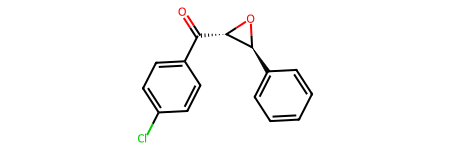

Observed ee: 1   Predicted ee: 1


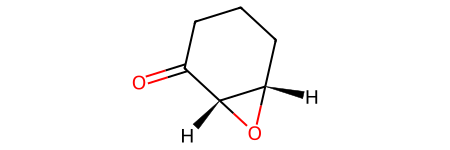

Observed ee: 1   Predicted ee: 1


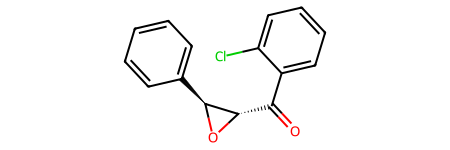

Observed ee: 1   Predicted ee: 1


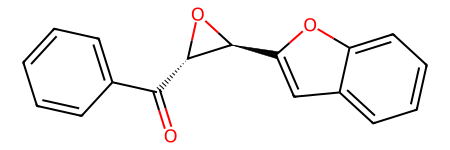

Observed ee: 1   Predicted ee: 1


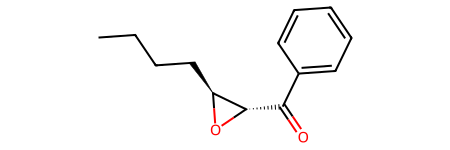

Observed ee: 0   Predicted ee: 0


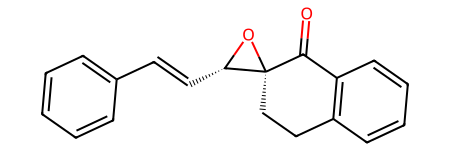

Observed ee: 0   Predicted ee: 0


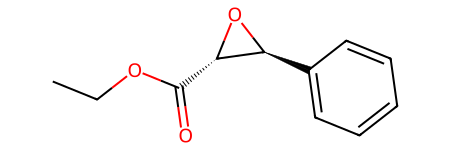

Observed ee: 1   Predicted ee: 1


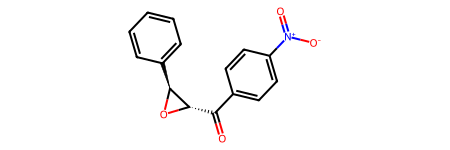

Observed ee: 1   Predicted ee: 1


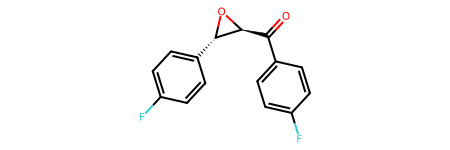

In [50]:

from rdkit import Chem
from IPython.display import display

for x in range(len(y_pred_val)):
    print("Observed ee: " + str(data['epox_cla'][x]) + '   ' + "Predicted ee: " + str(y_pred_val[x]))
    mol = Chem.MolFromSmiles(val_df['SMILES'][x])
    display(mol)


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings('ignore')


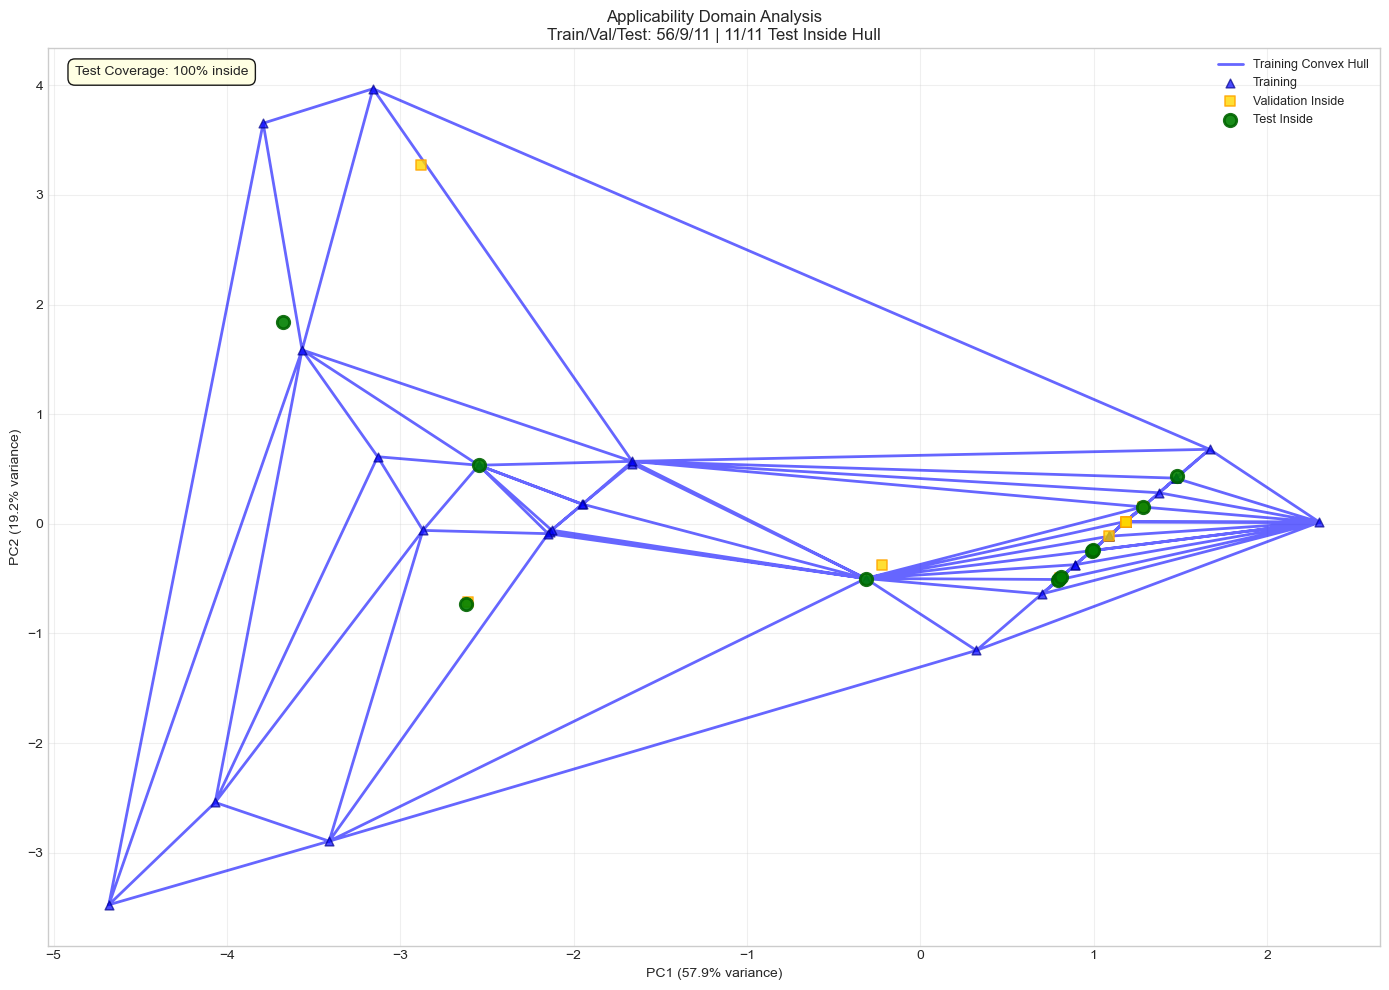

Outlier Analysis:

Summary: 11/11 test points inside hull (100.0%)
Detailed outlier info: {}


In [52]:
def analyze_applicability_detailed(X_train, X_val, X_test):
    """Single plot version"""
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    from scipy.spatial import Delaunay
    tri = Delaunay(X_train_pca)
    
    # Masks
    val_inside_mask = tri.find_simplex(X_val_pca) >= 0
    test_inside_mask = tri.find_simplex(X_test_pca) >= 0

    # Distance calculation
    def point_to_hull_distance(point, tri, X_train_pca):
        """Stable distance to convex hull"""
        min_dist = np.inf
        
        # 1. To vertices
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        # 2. To edges
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        center = np.mean(X_train_pca, axis=0)
        hull_radius = np.mean(np.linalg.norm(X_train_pca - center, axis=1))
        
        total_min_dist = min(dist_vertices, min_edge_dist)
        
        return {
            'dist_to_hull': total_min_dist,
            'dist_to_edge': min_edge_dist,
            'dist_to_vertex': dist_vertices,
            'hull_radius': hull_radius,
            'relative_dist_%': (total_min_dist / hull_radius) * 100
        }

    # Analyze outliers
    outlier_info = {}
    outlier_descriptions = []
    for i, is_inside in enumerate(test_inside_mask):
        if not is_inside:
            info = point_to_hull_distance(X_test_pca[i], tri, X_train_pca)
            outlier_info[f'T{i}'] = info
            
            # English classification
            rel_dist = info['relative_dist_%']
            if rel_dist < 10:
                desc = "VERY CLOSE (<10%)"
            elif rel_dist < 25:
                desc = "CLOSE (10-25%)"
            else:
                desc = "FAR (>25%)"
            
            outlier_descriptions.append(f"T{i}: {desc} ({rel_dist:.1f}%)")

    # SINGLE PLOT - FULL FEATURES
    plt.figure(figsize=(14, 10))
    
    # Convex hull
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, 
                'b-', alpha=0.6, linewidth=2, label='Training Convex Hull')

    # Training points
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', s=40, 
                alpha=0.7, marker='^', edgecolors='darkblue', label='Training')

    # Validation points
    plt.scatter(X_val_pca[val_inside_mask, 0], X_val_pca[val_inside_mask, 1], 
                c='gold', s=60, marker='s', alpha=0.8, 
                edgecolors='orange', label='Validation Inside', linewidth=1.2)
    if np.any(~val_inside_mask):
        plt.scatter(X_val_pca[~val_inside_mask, 0], X_val_pca[~val_inside_mask, 1], 
                    c='orange', s=60, marker='s', alpha=0.8, 
                    edgecolors='darkorange', label='Validation Outside', linewidth=1.2)

    # Test inside
    plt.scatter(X_test_pca[test_inside_mask, 0], X_test_pca[test_inside_mask, 1], 
                c='green', s=80, alpha=0.9, edgecolors='darkgreen', 
                label='Test Inside', linewidth=2)

    # Test outside WITH DISTANCES
    test_outside_idx = np.where(~test_inside_mask)[0]
    for i, idx in enumerate(test_outside_idx):
        dist_pct = outlier_info[f'T{idx}']['relative_dist_%']
        color_intensity = min(dist_pct / 30, 1)
        color = (1, color_intensity*0.6, color_intensity*0.2)  # Red gradient
        
        plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], 
                   c=color, s=140, alpha=0.95, edgecolors='black', linewidth=3)
        
        # Distance annotation
        plt.annotate(f'T{idx}\n{dist_pct:.1f}%\nhull dist.', 
                    (X_test_pca[idx, 0], X_test_pca[idx, 1]), 
                    xytext=(12, 18), textcoords='offset points', fontsize=10,
                    color='white', fontweight='bold', ha='center',
                    bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.9))

    # Title and labels
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title(f'Applicability Domain Analysis\n'
              f'Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)} | '
              f'{np.sum(test_inside_mask)}/{len(test_inside_mask)} Test Inside Hull')
    
    # Legend with outlier summary
    legend_text = f"Test Coverage: {100*np.sum(test_inside_mask)/len(test_inside_mask):.0f}% inside"
    if outlier_descriptions:
        legend_text += f"\nOutliers: {', '.join(outlier_descriptions)}"
    
    plt.text(0.02, 0.98, legend_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.9))
    
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save publication-ready
    plt.savefig('applicability_domain_single_plot.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('applicability_domain_single_plot.svg', dpi=300, bbox_inches='tight')
    plt.savefig('applicability_domain_single_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Outlier Analysis:")
    for desc in outlier_descriptions:
        print(f"  {desc}")
    print(f"\nSummary: {np.sum(test_inside_mask)}/{len(test_inside_mask)} test points inside hull "
          f"({100*np.sum(test_inside_mask)/len(test_inside_mask):.1f}%)")
    
    return {
        'test_inside_mask': test_inside_mask,
        'val_inside_mask': val_inside_mask,
        'outlier_info': outlier_info,
        'outlier_descriptions': outlier_descriptions
    }

# USAGE:
result = analyze_applicability_detailed(X_train, data[list(X_train.columns)], X_test)
print("Detailed outlier info:", result['outlier_info'])


In [53]:
def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    
    Heuristic Logic:
    - Inside Hull -> In Domain
    - Outside Hull:
        - rel_dist = dist_to_hull / dist_to_centroid
        - if rel_dist < threshold -> In Domain (Extended)
        - if rel_dist >= threshold -> Out of Domain
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay)
    tri = Delaunay(X_train_pca)
    
    # Basic containment check
    val_inside_mask = tri.find_simplex(X_val_pca) >= 0
    test_inside_mask = tri.find_simplex(X_test_pca) >= 0
    
    # Geometric center of training data (Centroid)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        # 1. To vertices
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        # 2. To edges
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        # Avoid division by zero
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return {
            'r_d_hull': r_d_hull,
            'r_geometrical_center': r_geometrical_center,
            'rel_distance': rel_distance
        }

    # 4. Analyze Test Points with Heuristic
    test_status = [] # 'inside', 'extended', 'out'
    outlier_details = {}
    
    for i in range(len(X_test_pca)):
        if test_inside_mask[i]:
            test_status.append('inside')
        else:
            # Calculate heuristic metrics
            info = get_hull_distance_info(X_test_pca[i], tri, X_train_pca, centroid_train)
            rel_dist = info['rel_distance']
            
            outlier_details[f'T{i}'] = info
            
            if rel_dist < heuristic_threshold:
                test_status.append('extended') # Outside hull but acceptable
            else:
                test_status.append('out') # Outside hull and unacceptable

    test_status = np.array(test_status)

    # 5. PLOTTING
    plt.figure(figsize=(12, 9))
    
    # A. Draw Hull
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, 
                color='gray', alpha=0.4, linewidth=1, label='Training Convex Hull')

    # B. Plot Points
    # Training
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', s=30, 
                alpha=0.5, marker='o', label='Training Data')

    # Validation (Optional visualization)
    plt.scatter(X_val_pca[:, 0], X_val_pca[:, 1], c='orange', s=30, marker='s', alpha=0.6, label='Validation')

    # Test: Inside Hull (Safe)
    mask_in = test_status == 'inside'
    if np.any(mask_in):
        plt.scatter(X_test_pca[mask_in, 0], X_test_pca[mask_in, 1], 
                   c='green', s=80, alpha=0.9, edgecolors='darkgreen', 
                   label='Test: Inside Hull (Safe)')

    # Test: Extended Domain (Heuristic Acceptable)
    mask_ext = test_status == 'extended'
    if np.any(mask_ext):
        plt.scatter(X_test_pca[mask_ext, 0], X_test_pca[mask_ext, 1], 
                   c='yellowgreen', s=100, marker='D', alpha=0.9, edgecolors='black', 
                   label=f'Test: Extended Domain (rel_dist < {heuristic_threshold})')
        
        # Annotate extended points
        for idx in np.where(mask_ext)[0]:
            info = outlier_details[f'T{idx}']
            plt.annotate(f"T{idx}\n{info['rel_distance']:.2f}", 
                         (X_test_pca[idx, 0], X_test_pca[idx, 1]),
                         xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8)

    # Test: Out of Domain
    mask_out = test_status == 'out'
    if np.any(mask_out):
        plt.scatter(X_test_pca[mask_out, 0], X_test_pca[mask_out, 1], 
                   c='red', s=120, marker='X', alpha=0.9, edgecolors='black', 
                   label=f'Test: Out of Domain (rel_dist >= {heuristic_threshold})')

        # Annotate outliers
        for idx in np.where(mask_out)[0]:
            info = outlier_details[f'T{idx}']
            plt.annotate(f"T{idx}\n{info['rel_distance']:.2f}", 
                         (X_test_pca[idx, 0], X_test_pca[idx, 1]),
                         xytext=(0, 10), textcoords='offset points', ha='center', 
                         color='red', fontweight='bold', fontsize=9)

    # Plot Centroid
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, linewidth=2, label='Train Centroid')

    # Formatting
    plt.title(f'Applicability Domain Analysis (Heuristic Threshold = {heuristic_threshold})\n'
              f'Total Test: {len(X_test)} | Safe: {np.sum(mask_in)} | '
              f'Extended: {np.sum(mask_ext)} | Outliers: {np.sum(mask_out)}')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    plt.legend(loc='upper right', frameon=True, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save
    plt.savefig('AD_heuristic_plot.svg', dpi=300)
    plt.show()

    # Text Summary
    print("-" * 50)
    print("HEURISTIC SUMMARY")
    print("-" * 50)
    print(f"Threshold (rel_distance): {heuristic_threshold}")
    print(f"Inside Hull (Safe):       {np.sum(mask_in)}")
    print(f"Extended Domain (Safe):   {np.sum(mask_ext)}")
    print(f"Out of Domain (Unsafe):   {np.sum(mask_out)}")
    print("-" * 50)
    
    if len(outlier_details) > 0:
        print("\nDetails for points outside hull:")
        print(f"{'ID':<5} | {'r_hull':<10} | {'r_center':<10} | {'rel_dist':<10} | {'Status'}")
        for idx_str, info in outlier_details.items():
            status = "EXTENDED" if info['rel_distance'] < heuristic_threshold else "OUT"
            print(f"{idx_str:<5} | {info['r_d_hull']:.4f}     | {info['r_geometrical_center']:.4f}     | {info['rel_distance']:.4f}     | {status}")

    return {
        'test_status': test_status,
        'outlier_details': outlier_details,
        'mask_in': mask_in,
        'mask_extended': mask_ext,
        'mask_out': mask_out
    }

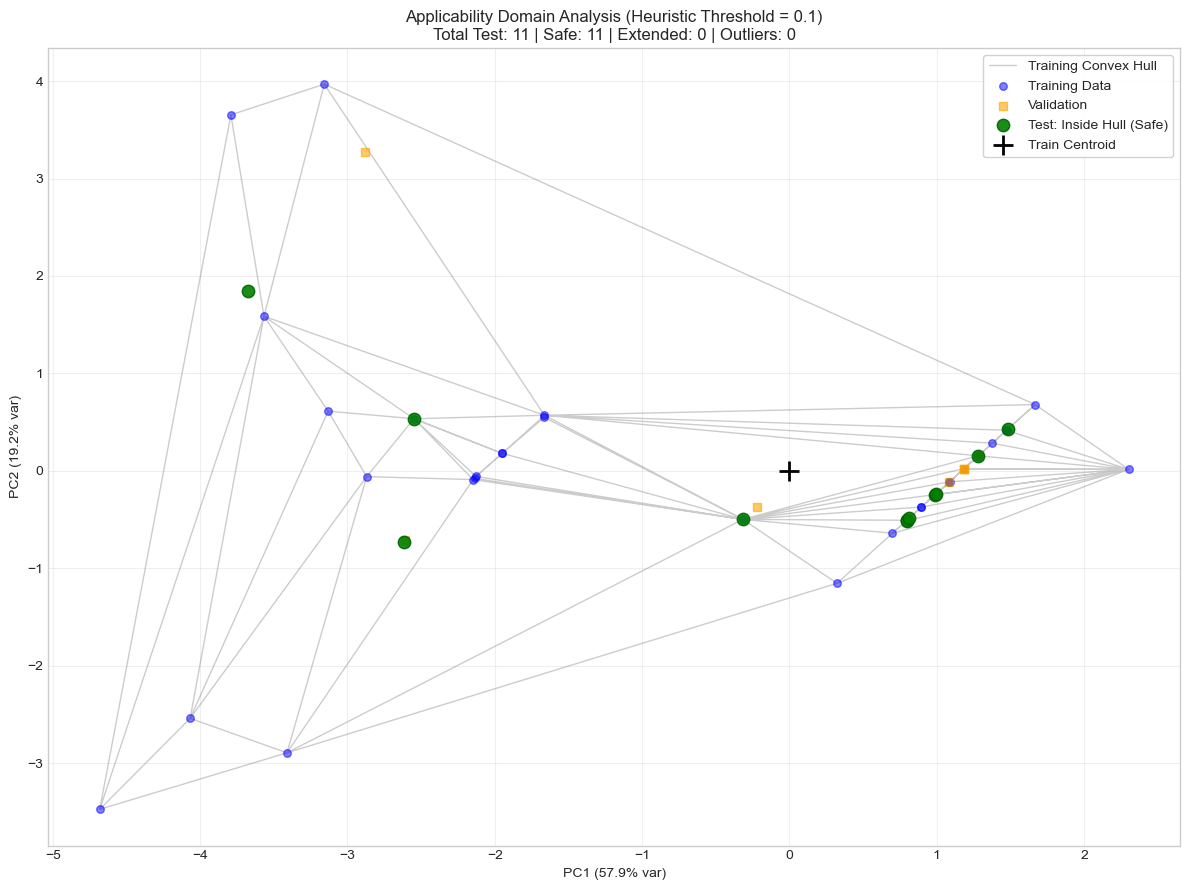

--------------------------------------------------
HEURISTIC SUMMARY
--------------------------------------------------
Threshold (rel_distance): 0.1
Inside Hull (Safe):       11
Extended Domain (Safe):   0
Out of Domain (Unsafe):   0
--------------------------------------------------


In [54]:
result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [55]:
CONFIG = {
    # Data file
    'data': './Data/exp_verification.xlsx',
    'target_col': 'epox_cla',
    'name': 'exp_set',
    'mode': 'exp',
    'output_dir': './Data/'
}

In [56]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/exp_verification.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: False
 Morgan FP: False
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: False

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_exp_set_.parquet
Shape: (36, 313)
Returning: full descriptor set

 Data loaded and ALL descriptors calculated
  Total samples: 36
 

In [57]:
data[list(X_train.columns)]

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C
0,2.062840,3.618626,2,8,1,1
1,2.067437,3.614964,2,9,1,1
2,2.068298,3.617124,0,9,0,0
3,2.067219,3.616307,2,8,1,1
4,2.067355,3.617116,2,13,1,1
5,2.067078,3.616891,2,8,1,1
6,2.067696,3.617337,2,8,1,1
7,2.069617,3.621353,2,9,1,1
8,2.063188,3.619607,2,8,1,1
9,2.066939,3.616809,2,8,1,1


In [58]:
y_pred_exp = model.predict(data[list(X_train.columns)])

In [59]:
val_acc, val_bal_acc, val_f1 = summarize_performance(data['epox_cla'], y_pred_exp, "EXP")

print("╔════════════════════════════╦═══════════════════════════╗")
print("║          Metric            ║      EXP Set       ║")
print("╠════════════════════════════╬═══════════════════════════╣")
print(f"║ Accuracy                   ║   {val_acc:.4f}                  ║")
print(f"║ Balanced Accuracy          ║   {val_bal_acc:.4f}                  ║")
print(f"║ F1 (macro)                 ║   {val_f1:.4f}                  ║")
print("╚════════════════════════════╩═══════════════════════════╝")


[EXP]
  Accuracy          : 0.8056
  Balanced Accuracy : 0.8478
  F1 (macro)        : 0.8042
╔════════════════════════════╦═══════════════════════════╗
║          Metric            ║      EXP Set       ║
╠════════════════════════════╬═══════════════════════════╣
║ Accuracy                   ║   0.8056                  ║
║ Balanced Accuracy          ║   0.8478                  ║
║ F1 (macro)                 ║   0.8042                  ║
╚════════════════════════════╩═══════════════════════════╝


In [60]:


for x in range(len(y_pred_exp)):

    print("Observed ee: " + str(data['epox_cla'][x]) + '   ' + "Predicted ee: " +str(y_pred_exp[x]))

Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 0   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 0   Predicted ee: 1
Observed ee: 0   Predicted ee: 1
Observed ee: 1   Predicted ee: 1
Observed ee: 0   Predicted ee: 1
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 1
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed ee: 1   Predicted ee: 1
Observed ee: 0   Predicted ee: 0
Observed ee: 0   Predicted ee: 0
Observed e

In [61]:
exp_data = './Data/exp_verification.xlsx'


# Load the datasets
exp_df = pd.read_excel(exp_data)
exp_df.head(1)

,l.p,SMILES__,SMILES,ee,epox_cla
0,10,C=CC1=CC(/C=C/C(C2=C(C=CC=C2)Br)=O)=CC=C1,C=CC1=CC([C@@H]2O[C@H]2C(C3=C(Br)C=CC=C3)=O)=C...,92,1


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    Returns dictionaries containing processed DataFrames for Experimental (Val) and Test sets,
    printing indices of molecules outside the safe domain.
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay) on Training Data
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return rel_distance

    # 4. Universal Function to Process Any Dataset
    def process_dataset(X_data, X_pca_data, dataset_name="Data"):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            
            indices = X_data.index.tolist()
        else:
            df_out = pd.DataFrame(X_data)
            indices = list(range(len(X_data)))
            
        is_inside = tri.find_simplex(X_pca_data) >= 0
        
        status_list = []
        rel_dist_list = []
        
        for i in range(len(X_pca_data)):
            if is_inside[i]:
                status_list.append('Inside Hull')
                rel_dist_list.append(0.0) 
            else:
                rel_dist = get_hull_distance_info(X_pca_data[i], tri, X_train_pca, centroid_train)
                rel_dist_list.append(rel_dist)
                
                if rel_dist < heuristic_threshold:
                    status_list.append('Extended Domain')
                else:
                    status_list.append('Out of Domain')
        
        df_out['AD_Status'] = status_list
        df_out['Rel_Distance'] = rel_dist_list
        #
        df_out['Original_Index'] = indices
        
        return df_out, np.array(status_list)

    # 5. Apply Logic
    print("Processing Experimental Data...")
    X_val_df, val_statuses = process_dataset(X_val, X_val_pca, "Experimental")
    
    print("Processing Test Data...")
    X_test_df, test_statuses = process_dataset(X_test, X_test_pca, "Test")

    # 6. PLOTTING
    plt.figure(figsize=(12, 9))
    
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, color='gray', alpha=0.4)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', alpha=0.3, label='Training Data')
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, label='Centroid')

    style_map = {
        'Inside Hull':     {'c': 'green', 'm': 'o', 'alpha': 0.6},
        'Extended Domain': {'c': 'orange', 'm': 'D', 'alpha': 0.8},
        'Out of Domain':   {'c': 'red',   'm': 'X', 'alpha': 0.9}
    }

    # Helper function to plot and annotate
    def plot_subset(df, pca_data, label_prefix, marker_style):
        for status in style_map:
            mask = df['AD_Status'] == status
            if mask.any():
                plt.scatter(pca_data[mask, 0], pca_data[mask, 1], 
                            c=style_map[status]['c'], marker=marker_style, s=60, edgecolors='black',
                            label=f'{label_prefix}: {status}')
                
                # Annotation for non-Inside points
                if status in ['Out of Domain', 'Extended Domain']:
                    idxs = np.where(mask)[0]
                    for idx in idxs:
                        dist = df.iloc[idx]['Rel_Distance']
                        mol_idx = df.iloc[idx]['Original_Index']
                        
                        #"Index: Distance annotation format"
                        label_text = f"#{mol_idx}\n{dist:.2f}"
                        
                        plt.annotate(label_text, 
                                     (pca_data[idx, 0], pca_data[idx, 1]),
                                     xytext=(5, 5), textcoords='offset points', 
                                     fontsize=8, fontweight='bold', color='black',
                                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

    plot_subset(X_val_df, X_val_pca, "Exp", 's')
    plot_subset(X_test_df, X_test_pca, "Test", 'P')

    plt.title(f'Applicability Domain (Threshold={heuristic_threshold})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('applicability_domain_experimental_set.svg', dpi=300, bbox_inches='tight')
    plt.show()

    # 7. Summary Print with Indices
    def print_outliers(df, name):
        print(f"\n--- Detailed Report: {name} Set ---")
        counts = df['AD_Status'].value_counts()
        print(counts)
        
        for status in ['Extended Domain', 'Out of Domain']:
            subset = df[df['AD_Status'] == status]
            if not subset.empty:
                print(f"\n[{status}] Molecules (Index -> Rel_Distance):")
                for _, row in subset.iterrows():
                    print(f"  - Index {row['Original_Index']}: {row['Rel_Distance']:.4f}")
            else:
                print(f"\n[{status}]: None")

    print_outliers(X_val_df, "Experimental")
    print_outliers(X_test_df, "Test")

    return {
        'exp_results_df': X_val_df,
        'test_results_df': X_test_df
    }


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analizuje domenę stosowalności z użyciem otoczki wypukłej i heurystyki odległości.
    Zwraca słowniki zawierające przetworzone DataFrame dla zbioru eksperymentalnego
    i testowego oraz wypisuje indeksy cząsteczek znajdujących się poza bezpiecznym obszarem.
    """
    
    # 1. Skalowanie i PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Otoczka wypukła (Delaunay) dla danych treningowych
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Funkcja pomocnicza: obliczanie odległości od otoczki
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Odległość od otoczki (podejście geometryczne)
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0, 1], [1, 2], [2, 0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Odległość od środka geometrycznego (centroidu)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Względny współczynnik odległości
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return rel_distance

    # 4. Uniwersalna funkcja do przetwarzania dowolnego zbioru danych
    def process_dataset(X_data, X_pca_data, dataset_name="Dane"):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            indices = X_data.index.tolist()
        else:
            df_out = pd.DataFrame(X_data)
            indices = list(range(len(X_data)))
            
        is_inside = tri.find_simplex(X_pca_data) >= 0
        
        status_list = []
        rel_dist_list = []
        
        for i in range(len(X_pca_data)):
            if is_inside[i]:
                status_list.append('Wewnątrz otoczki')
                rel_dist_list.append(0.0)
            else:
                rel_dist = get_hull_distance_info(X_pca_data[i], tri, X_train_pca, centroid_train)
                rel_dist_list.append(rel_dist)
                
                if rel_dist < heuristic_threshold:
                    status_list.append('Rozszerzona domena')
                else:
                    status_list.append('Poza domeną')
        
        df_out['Status_AD'] = status_list
        df_out['Względna_odległość'] = rel_dist_list
        df_out['Indeks_oryginalny'] = indices
        
        return df_out, np.array(status_list)

    # 5. Zastosowanie logiki
    print("Przetwarzanie danych eksperymentalnych...")
    X_val_df, val_statuses = process_dataset(X_val, X_val_pca, "Eksperymentalny")
    
    print("Przetwarzanie danych testowych...")
    X_test_df, test_statuses = process_dataset(X_test, X_test_pca, "Testowy")

    # 6. Wykres
    plt.figure(figsize=(14, 10))
    
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, color='gray', alpha=0.4)
    plt.scatter(
        X_train_pca[:, 0], X_train_pca[:, 1],
        c='blue', alpha=0.3, s=80, label='Dane treningowe'
    )
    plt.scatter(
        centroid_train[0], centroid_train[1],
        c='black', marker='+', s=260, linewidths=2.5, label='Centroid'
    )

    style_map = {
        'Wewnątrz otoczki': {'c': 'green', 'm': 'o', 'alpha': 0.6},
        'Rozszerzona domena': {'c': 'orange', 'm': 'D', 'alpha': 0.8},
        'Poza domeną': {'c': 'red', 'm': 'X', 'alpha': 0.9}
    }

    # Funkcja pomocnicza do rysowania i adnotacji
    def plot_subset(df, pca_data, label_prefix, marker_style):
        for status in style_map:
            mask = df['Status_AD'] == status
            if mask.any():
                plt.scatter(
                    pca_data[mask, 0], pca_data[mask, 1],
                    c=style_map[status]['c'],
                    marker=marker_style,
                    s=110,
                    edgecolors='black',
                    linewidths=1.2,
                    label=f'{label_prefix}: {status}'
                )
                
                if status in ['Poza domeną', 'Rozszerzona domena']:
                    idxs = np.where(mask)[0]
                    for idx in idxs:
                        dist = df.iloc[idx]['Względna_odległość']
                        mol_idx = df.iloc[idx]['Indeks_oryginalny']
                        
                        label_text = f"#{mol_idx}\n{dist:.2f}"
                        
                        plt.annotate(
                            label_text,
                            (pca_data[idx, 0], pca_data[idx, 1]),
                            xytext=(6, 6),
                            textcoords='offset points',
                            fontsize=16,
                            fontweight='bold',
                            color='black',
                            bbox=dict(
                                boxstyle="round,pad=0.25",
                                fc="white",
                                alpha=0.7
                            )
                        )

    plot_subset(X_val_df, X_val_pca, "Eksperymentalny", 's')
    plot_subset(X_test_df, X_test_pca, "Test", 'P')

    plt.title(f'Domena stosowalności (próg = {heuristic_threshold})', fontsize=22)
    plt.xlabel('PC1', fontsize=20)
    plt.ylabel('PC2', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        fontsize=18,
        title='Legenda',
        title_fontsize=18
    )
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('applicability_domain_experimental_set.svg', dpi=300, bbox_inches='tight')
    plt.show()

    # 7. Raport tekstowy z indeksami
    def print_outliers(df, name):
        print(f"\n--- Raport szczegółowy: zbiór {name} ---")
        counts = df['Status_AD'].value_counts()
        print(counts)
        
        for status in ['Rozszerzona domena', 'Poza domeną']:
            subset = df[df['Status_AD'] == status]
            if not subset.empty:
                print(f"\n[{status}] Cząsteczki (indeks -> względna odległość):")
                for _, row in subset.iterrows():
                    print(f"  - Indeks {row['Indeks_oryginalny']}: {row['Względna_odległość']:.4f}")
            else:
                print(f"\n[{status}]: brak")

    print_outliers(X_val_df, "eksperymentalny")
    print_outliers(X_test_df, "testowy")

    return {
        'exp_results_df': X_val_df,
        'test_results_df': X_test_df
    }

Przetwarzanie danych eksperymentalnych...
Przetwarzanie danych testowych...


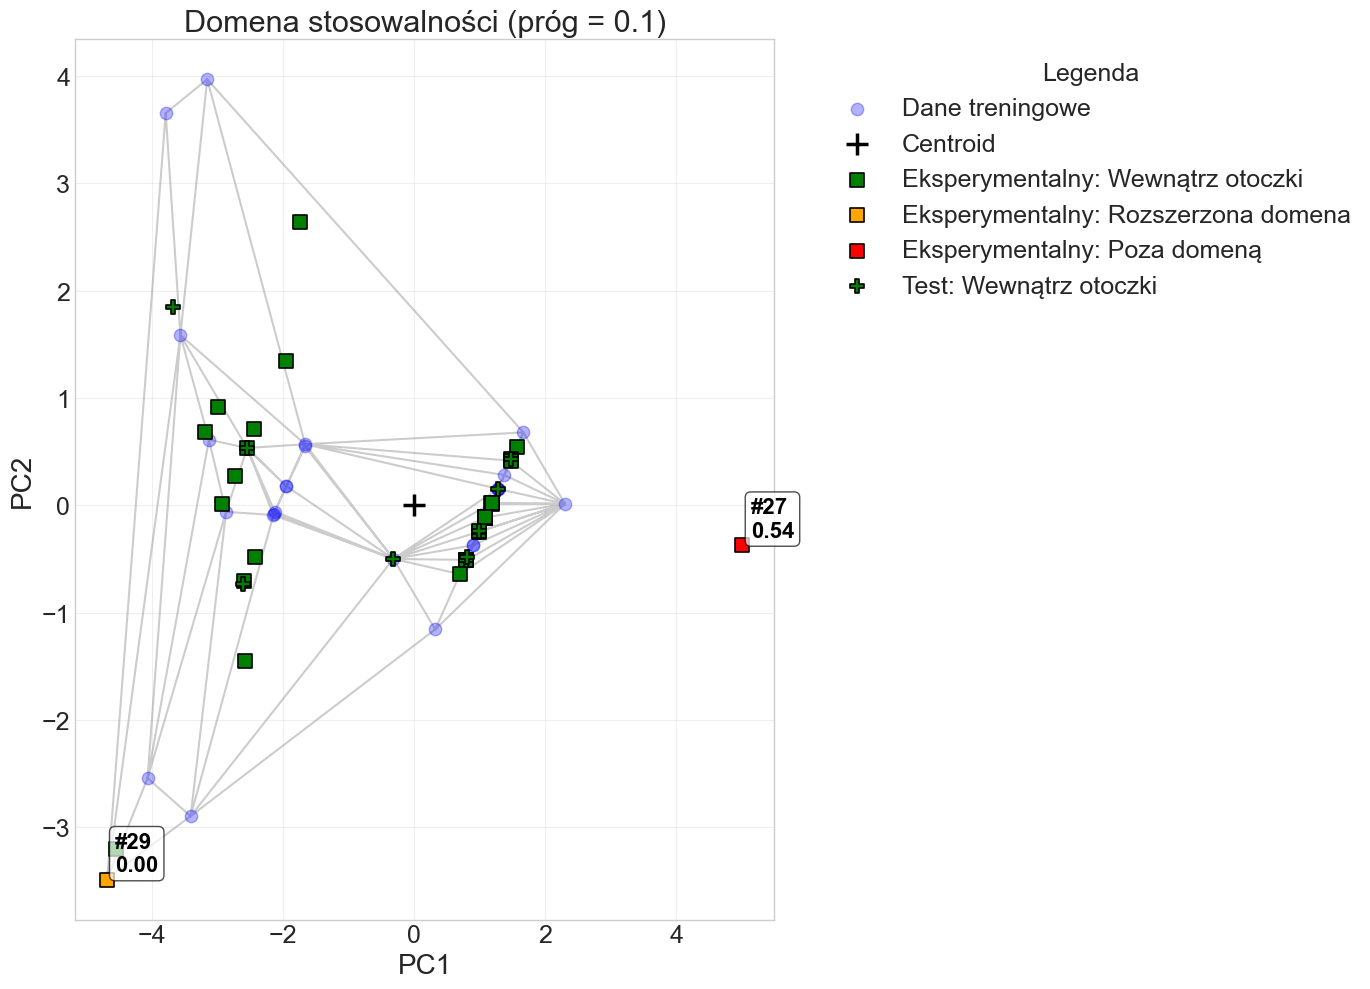


--- Raport szczegółowy: zbiór eksperymentalny ---
Status_AD
Wewnątrz otoczki      34
Poza domeną            1
Rozszerzona domena     1
Name: count, dtype: int64

[Rozszerzona domena] Cząsteczki (indeks -> względna odległość):
  - Indeks 29: 0.0025

[Poza domeną] Cząsteczki (indeks -> względna odległość):
  - Indeks 27: 0.5446

--- Raport szczegółowy: zbiór testowy ---
Status_AD
Wewnątrz otoczki    11
Name: count, dtype: int64

[Rozszerzona domena]: brak

[Poza domeną]: brak


In [64]:
result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [65]:
result['exp_results_df']

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C,Status_AD,Względna_odległość,Indeks_oryginalny
0,2.062840,3.618626,2,8,1,1,Wewnątrz otoczki,0.000000,0
1,2.067437,3.614964,2,9,1,1,Wewnątrz otoczki,0.000000,1
2,2.068298,3.617124,0,9,0,0,Wewnątrz otoczki,0.000000,2
3,2.067219,3.616307,2,8,1,1,Wewnątrz otoczki,0.000000,3
4,2.067355,3.617116,2,13,1,1,Wewnątrz otoczki,0.000000,4
5,2.067078,3.616891,2,8,1,1,Wewnątrz otoczki,0.000000,5
6,2.067696,3.617337,2,8,1,1,Wewnątrz otoczki,0.000000,6
7,2.069617,3.621353,2,9,1,1,Wewnątrz otoczki,0.000000,7
8,2.063188,3.619607,2,8,1,1,Wewnątrz otoczki,0.000000,8
9,2.066939,3.616809,2,8,1,1,Wewnątrz otoczki,0.000000,9


In [66]:
result['test_results_df']

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C,Status_AD,Względna_odległość,Indeks_oryginalny
index,,,,,,,,,
1,2.069732,3.616699,0,9,0,0,Wewnątrz otoczki,0.0,1
31,2.065959,3.616981,2,7,1,1,Wewnątrz otoczki,0.0,31
26,2.063133,3.614390,2,5,1,1,Wewnątrz otoczki,0.0,26
51,2.077087,6.481032,0,5,0,0,Wewnątrz otoczki,0.0,51
44,2.061182,3.613506,2,7,1,1,Wewnątrz otoczki,0.0,44
32,2.053431,3.618200,2,12,1,1,Wewnątrz otoczki,0.0,32
21,2.065017,3.618622,2,10,1,1,Wewnątrz otoczki,0.0,21
11,2.052098,3.610307,1,0,0,0,Wewnątrz otoczki,0.0,11
47,2.067440,3.614784,2,5,1,1,Wewnątrz otoczki,0.0,47


In [67]:
fig = exp_df
fig['predicted_ee'] = y_pred_exp
fig.head()

,l.p,SMILES__,SMILES,ee,epox_cla,predicted_ee
0,10,C=CC1=CC(/C=C/C(C2=C(C=CC=C2)Br)=O)=CC=C1,C=CC1=CC([C@@H]2O[C@H]2C(C3=C(Br)C=CC=C3)=O)=C...,92,1,1
1,11,O=C(/C=C/C1=CC=CC=C1)C2=CC=CC=C2Br,O=C(C1=CC=CC=C1Br)[C@H]2[C@H](C3=CC=CC=C3)O2,89,1,1
2,12,O=C(/C=C/C1=C(Br)C=CC=C1)C2=CC=CC=C2,O=C([C@@H]1[C@H](O1)C2=C(Br)C=CC=C2)C3=CC=CC=C3,11,1,1
3,13,O=C(/C=C/C1=CC=CC(C(OC)OC)=C1)C2=C(Br)C=CC=C2,O=C(C1=C(C=CC=C1)Br)[C@H]2[C@H](C3=CC=CC(C(OC)...,87,1,1
4,14,O=C(/C=C/C1=CC=C(OC2=CC=CC=C2)C=C1)C3=CC=C([N+...,O=C(C1=CC=C(C=C1)[N+]([O-])=O)[C@H]2[C@H](C3=C...,90,1,1


In [68]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

KeyError: 'AD_Status'

In [69]:
from rdkit import Chem
from rdkit.Chem import Draw

from rdkit.Chem.Draw import rdMolDraw2D

def draw_molgrid_with_results(df, 
                              smiles_col='SMILES', 
                              obs_col='epox_cla', 
                              pred_col='predicted_ee',
                              hull_col='AD_Status',
                              n_per_row=8, 
                              max_mols=100, 
                              img_size=(400, 400)):

    mols = []
    legends = []
    
    df_subset = df.head(max_mols)
    
    for idx, row in df_subset.iterrows():
        smi = row[smiles_col]
        obs = row[obs_col]
        pred = row[pred_col]
        hull = row[hull_col]
        
        mol = Chem.MolFromSmiles(smi)
        
        if mol is not None:
            mols.append(mol)
            
            error = abs(obs - pred)

            label = f"Obs: {obs:.1f} | Pred: {pred:.1f} | Err: {error:.1f} \n AD Status: {hull}"
            legends.append(label)
        else:
            print(f"SMILES processing issue for index {idx}: {smi}")

    dopts = rdMolDraw2D.MolDrawOptions()
    
    dopts.legendFontSize = 50  
    
    #dopts.padding = 0.02  

    dopts.bondLineWidth = 4
    

    img = Draw.MolsToGridImage(
        mols, 
        molsPerRow=n_per_row, 
        subImgSize=img_size, 
        legends=legends,
        useSVG=True,
        drawOptions=dopts
    )
    
    return img


In [70]:
img = draw_molgrid_with_results(fig, max_mols=100)
display(img)

KeyError: 'AD_Status'

In [71]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

KeyError: 'AD_Status'

In [72]:
fig['epox_cla'][fig['AD_Status'] == 'Inside Hull']

KeyError: 'AD_Status'

In [73]:
val_acc, val_bal_acc, val_f1 = summarize_performance(fig['epox_cla'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull'], "EXP")

print("╔════════════════════════════╦═══════════════════════════╗")
print("║          Metric            ║      EXP Inside Hull Set       ║")
print("╠════════════════════════════╬═══════════════════════════╣")
print(f"║ Accuracy                   ║   {val_acc:.4f}                  ║")
print(f"║ Balanced Accuracy          ║   {val_bal_acc:.4f}                  ║")
print(f"║ F1 (macro)                 ║   {val_f1:.4f}                  ║")
print("╚════════════════════════════╩═══════════════════════════╝")

KeyError: 'AD_Status'

In [74]:
len(fig['epox_cla'][fig['AD_Status'] == 'Inside Hull'])

KeyError: 'AD_Status'

In [75]:
val_acc, val_bal_acc, val_f1 = summarize_performance(fig['epox_cla'][fig['AD_Status'] != 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] != 'Inside Hull'], "EXP")

print("╔════════════════════════════╦═══════════════════════════╗")
print("║          Metric            ║      EXP Outside Hull Set       ║")
print("╠════════════════════════════╬═══════════════════════════╣")
print(f"║ Accuracy                   ║   {val_acc:.4f}                  ║")
print(f"║ Balanced Accuracy          ║   {val_bal_acc:.4f}                  ║")
print(f"║ F1 (macro)                 ║   {val_f1:.4f}                  ║")
print("╚════════════════════════════╩═══════════════════════════╝")

KeyError: 'AD_Status'

In [76]:
len(fig['epox_cla'][fig['AD_Status'] != 'Inside Hull'])

KeyError: 'AD_Status'

In [77]:
## see test structure which are outside hull

In [78]:
test = pd.read_excel('./Data/initial_vs_new_SMILES_models_.xlsx')

In [79]:
test.head()

,Unnamed: 0,Initial_SMILES,New_SMILES,epox_cla,dataset,Sterimol_Beta_R1_L,Sterimol_Beta_R1_B1,Sterimol_Beta_R1_B5,Sterimol_Beta_R2_L,Sterimol_Beta_R2_B1,...,Beta_R1_Charge_Head,Beta_R1_Charge_Sum3,Beta_R2_EN,Beta_R2_Charge_Head,Beta_R2_Charge_Sum3,Alpha_R1_EN,Alpha_R1_Charge_Head,Alpha_R1_Charge_Sum3,Diff_Charge_Beta_Alpha,Diff_Charge_Acceptor_Alpha
0,0,CC3=CC=C(C=C3)[C@@H]4O[C@H]4C(C5=CC=CC=C5)=O,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccc(C)cc1,1,train,6.943624,1.7,6.934047,3.616927,1.7,...,-0.016162,0.045083,2.2,0.068867,-0.169602,2.20,0.072318,0.417996,-0.034241,0.042593
1,1,ClC3=CC=CC=C3[C@@H]4[C@@H](C(C5=CC=CC=C5)=O)O4,[C@H]1(C(=O)c2ccccc2)O[C@@H]1c1ccccc1Cl,1,test,5.848231,1.7,5.758544,3.616699,1.7,...,0.002499,0.066412,2.2,0.068922,-0.168056,2.20,0.072319,0.418054,-0.032864,0.042538
2,2,ClC3=CC=C([C@@H]4O[C@H]4C(C5=CC=CC=C5)=O)C=C3,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccc(Cl)cc1,1,train,6.645189,1.7,7.011927,3.617434,1.7,...,-0.016078,0.046385,2.2,0.068867,-0.169601,2.20,0.072318,0.417996,-0.034240,0.042593
3,3,[H][C@]1(O[C@@]1([H])C1=CC=CC=C1)C(=O)C1=CC=CC=C1,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccccc1,1,train,5.743783,1.7,5.818045,3.616975,1.7,...,-0.016182,0.044799,2.2,0.068867,-0.169603,2.20,0.072318,0.417996,-0.034241,0.042593
4,4,O=C4C5=CC=CC=C5CC[C@]46O[C@H]6C7=CC=CC=C7,[C@]12(CCc3ccccc3C1=O)O[C@H]2c1ccccc1,1,train,5.878383,1.7,5.730263,3.629593,1.7,...,-0.015871,0.048331,2.2,0.069200,-0.162500,2.55,-0.009194,0.129144,-0.041663,0.035333


In [80]:
test = test[test['dataset'] == 'test']
test

,Unnamed: 0,Initial_SMILES,New_SMILES,epox_cla,dataset,Sterimol_Beta_R1_L,Sterimol_Beta_R1_B1,Sterimol_Beta_R1_B5,Sterimol_Beta_R2_L,Sterimol_Beta_R2_B1,...,Beta_R1_Charge_Head,Beta_R1_Charge_Sum3,Beta_R2_EN,Beta_R2_Charge_Head,Beta_R2_Charge_Sum3,Alpha_R1_EN,Alpha_R1_Charge_Head,Alpha_R1_Charge_Sum3,Diff_Charge_Beta_Alpha,Diff_Charge_Acceptor_Alpha
1,1,ClC3=CC=CC=C3[C@@H]4[C@@H](C(C5=CC=CC=C5)=O)O4,[C@H]1(C(=O)c2ccccc2)O[C@@H]1c1ccccc1Cl,1,test,5.848231,1.7,5.758544,3.616699,1.7,...,0.002499,0.066412,2.2,0.068922,-0.168056,2.20,0.072319,0.418054,-0.032864,0.042538
11,11,O=C2CCCC[C@@H]3O[C@H]23,[C@H]12O[C@H]1CCCCC2=O,1,test,4.883744,1.7,5.265682,3.610307,1.7,...,-0.023644,0.017955,2.2,0.063629,-0.205758,2.20,0.071508,-0.147553,-0.050325,0.021535
21,21,O=C(C4=CC5=CC=CC=C5S4)[C@@H]6O[C@H]6C7=CC=CC=C7,[C@@H]1(C(=O)c2cc3ccccc3s2)O[C@H]1c1ccccc1,1,test,5.736401,1.7,5.825119,3.618622,1.7,...,-0.016181,0.044834,2.2,0.068868,-0.169533,2.20,0.072351,0.428819,-0.035060,0.051675
26,26,C\C=C\[C@@H]1O[C@H]1C(=O)C1=CC=CC=C1,[C@@H]1(C(=O)c2ccccc2)O[C@H]1/C=C/C,1,test,5.456023,1.7,5.507089,3.614390,1.7,...,-0.057079,-0.035668,2.2,0.068219,-0.177811,2.20,0.072293,0.417318,-0.040515,0.043196
31,31,CN3C=CC=C3C([C@@H]4O[C@H]4C5=CC=CC=C5)=O,[C@@H]1(C(=O)c2cccn2C)O[C@H]1c1ccccc1,1,test,5.741414,1.7,5.820190,3.616981,1.7,...,-0.016181,0.044865,2.2,0.068868,-0.169470,2.20,0.072382,0.435902,-0.035729,0.057329
32,32,O=C([C@@H]4O[C@H]4C5=CC=CC=C5)C6=C7C=CC=CC7=CC=C6,[C@@H]1(C(=O)c2cccc3ccccc23)O[C@H]1c1ccccc1,1,test,5.778765,1.7,5.804186,3.618200,1.7,...,-0.016182,0.044800,2.2,0.068867,-0.169602,2.20,0.072318,0.418645,-0.034265,0.043194
34,34,CC(C)[C@@H]2O[C@H]2C(C3=CC=CC=C3)=O,[C@@H]1(C(=O)c2ccccc2)O[C@H]1C(C)C,1,test,5.744619,1.7,4.134226,3.615890,1.7,...,-0.017584,0.016802,2.2,0.063921,-0.202102,2.20,0.071926,0.412854,-0.052603,0.046591
44,44,O=C(C3=CC=CC=C3)[C@@H]4O[C@H]4C5=CC=CN5,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccc[nH]1,0,test,5.403005,1.7,5.385045,3.613506,1.7,...,0.047349,0.140662,2.2,0.070438,-0.151831,2.20,0.072380,0.419637,-0.021149,0.041141
47,47,CCCCCCC([C@@H]2O[C@H]2C3=CC=CC=C3)=O,[C@@H]1(C(=O)CCCCCC)O[C@H]1c1ccccc1,0,test,5.746911,1.7,5.813877,3.614784,1.7,...,-0.016196,0.044388,2.2,0.068852,-0.170428,2.20,0.071911,0.382918,-0.029960,0.017279
51,51,O=C(C34[C@@H](C5=CC=CC=C5)O3)CCCC4=O,C12(O[C@@H]1c1ccccc1)C(=O)CCCC2=O,0,test,6.090907,1.7,5.569211,3.623988,1.7,...,-0.015383,0.056290,2.2,0.069714,-0.146796,2.55,0.174927,-0.110659,-0.086866,-0.039905


In [81]:
test['epox_cla']

1     1
11    1
21    1
26    1
31    1
32    1
34    1
44    0
47    0
51    0
63    0
Name: epox_cla, dtype: int64

In [82]:
X_test

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C
index,,,,,,
1,2.069732,3.616699,0,9,0,0
31,2.065959,3.616981,2,7,1,1
26,2.063133,3.614390,2,5,1,1
51,2.077087,6.481032,0,5,0,0
44,2.061182,3.613506,2,7,1,1
32,2.053431,3.618200,2,12,1,1
21,2.065017,3.618622,2,10,1,1
11,2.052098,3.610307,1,0,0,0
47,2.067440,3.614784,2,5,1,1


In [83]:
pred_test = model.predict(X_test)
pred_test.round(2)

array([1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [84]:
result['test_results_df']

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C,Status_AD,Względna_odległość,Indeks_oryginalny
index,,,,,,,,,
1,2.069732,3.616699,0,9,0,0,Wewnątrz otoczki,0.0,1
31,2.065959,3.616981,2,7,1,1,Wewnątrz otoczki,0.0,31
26,2.063133,3.614390,2,5,1,1,Wewnątrz otoczki,0.0,26
51,2.077087,6.481032,0,5,0,0,Wewnątrz otoczki,0.0,51
44,2.061182,3.613506,2,7,1,1,Wewnątrz otoczki,0.0,44
32,2.053431,3.618200,2,12,1,1,Wewnątrz otoczki,0.0,32
21,2.065017,3.618622,2,10,1,1,Wewnątrz otoczki,0.0,21
11,2.052098,3.610307,1,0,0,0,Wewnątrz otoczki,0.0,11
47,2.067440,3.614784,2,5,1,1,Wewnątrz otoczki,0.0,47


In [85]:
test_ = result['test_results_df']
test_

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C,Status_AD,Względna_odległość,Indeks_oryginalny
index,,,,,,,,,
1,2.069732,3.616699,0,9,0,0,Wewnątrz otoczki,0.0,1
31,2.065959,3.616981,2,7,1,1,Wewnątrz otoczki,0.0,31
26,2.063133,3.614390,2,5,1,1,Wewnątrz otoczki,0.0,26
51,2.077087,6.481032,0,5,0,0,Wewnątrz otoczki,0.0,51
44,2.061182,3.613506,2,7,1,1,Wewnątrz otoczki,0.0,44
32,2.053431,3.618200,2,12,1,1,Wewnątrz otoczki,0.0,32
21,2.065017,3.618622,2,10,1,1,Wewnątrz otoczki,0.0,21
11,2.052098,3.610307,1,0,0,0,Wewnątrz otoczki,0.0,11
47,2.067440,3.614784,2,5,1,1,Wewnątrz otoczki,0.0,47


In [86]:
test_ = test_.join(test[['New_SMILES', 'epox_cla']])
test_

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C,Status_AD,Względna_odległość,Indeks_oryginalny,New_SMILES,epox_cla
index,,,,,,,,,,,
1,2.069732,3.616699,0,9,0,0,Wewnątrz otoczki,0.0,1,[C@H]1(C(=O)c2ccccc2)O[C@@H]1c1ccccc1Cl,1
31,2.065959,3.616981,2,7,1,1,Wewnątrz otoczki,0.0,31,[C@@H]1(C(=O)c2cccn2C)O[C@H]1c1ccccc1,1
26,2.063133,3.614390,2,5,1,1,Wewnątrz otoczki,0.0,26,[C@@H]1(C(=O)c2ccccc2)O[C@H]1/C=C/C,1
51,2.077087,6.481032,0,5,0,0,Wewnątrz otoczki,0.0,51,C12(O[C@@H]1c1ccccc1)C(=O)CCCC2=O,0
44,2.061182,3.613506,2,7,1,1,Wewnątrz otoczki,0.0,44,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccc[nH]1,0
32,2.053431,3.618200,2,12,1,1,Wewnątrz otoczki,0.0,32,[C@@H]1(C(=O)c2cccc3ccccc23)O[C@H]1c1ccccc1,1
21,2.065017,3.618622,2,10,1,1,Wewnątrz otoczki,0.0,21,[C@@H]1(C(=O)c2cc3ccccc3s2)O[C@H]1c1ccccc1,1
11,2.052098,3.610307,1,0,0,0,Wewnątrz otoczki,0.0,11,[C@H]12O[C@H]1CCCCC2=O,1
47,2.067440,3.614784,2,5,1,1,Wewnątrz otoczki,0.0,47,[C@@H]1(C(=O)CCCCCC)O[C@H]1c1ccccc1,0


In [87]:
test_outside = test_
test_outside['AD_Status'] = result['test_results_df']['AD_Status']
test_outside['pred_ee'] = pred_test.round(2)
test_outside['Rel_Distance'] = result['test_results_df']['Rel_Distance']
test_outside = test_outside[test_outside['AD_Status'] != 'Inside Hull']

KeyError: 'AD_Status'

In [88]:
test_outside

,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,CircuS_r1-3_O1[C@@H](C)C1,CircuS_r1-3_ccc,CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C,CircuS_r1-3_[C@@H]1([C@H](C)O1)C,Status_AD,Względna_odległość,Indeks_oryginalny,New_SMILES,epox_cla
index,,,,,,,,,,,
1,2.069732,3.616699,0,9,0,0,Wewnątrz otoczki,0.0,1,[C@H]1(C(=O)c2ccccc2)O[C@@H]1c1ccccc1Cl,1
31,2.065959,3.616981,2,7,1,1,Wewnątrz otoczki,0.0,31,[C@@H]1(C(=O)c2cccn2C)O[C@H]1c1ccccc1,1
26,2.063133,3.614390,2,5,1,1,Wewnątrz otoczki,0.0,26,[C@@H]1(C(=O)c2ccccc2)O[C@H]1/C=C/C,1
51,2.077087,6.481032,0,5,0,0,Wewnątrz otoczki,0.0,51,C12(O[C@@H]1c1ccccc1)C(=O)CCCC2=O,0
44,2.061182,3.613506,2,7,1,1,Wewnątrz otoczki,0.0,44,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccc[nH]1,0
32,2.053431,3.618200,2,12,1,1,Wewnątrz otoczki,0.0,32,[C@@H]1(C(=O)c2cccc3ccccc23)O[C@H]1c1ccccc1,1
21,2.065017,3.618622,2,10,1,1,Wewnątrz otoczki,0.0,21,[C@@H]1(C(=O)c2cc3ccccc3s2)O[C@H]1c1ccccc1,1
11,2.052098,3.610307,1,0,0,0,Wewnątrz otoczki,0.0,11,[C@H]12O[C@H]1CCCCC2=O,1
47,2.067440,3.614784,2,5,1,1,Wewnątrz otoczki,0.0,47,[C@@H]1(C(=O)CCCCCC)O[C@H]1c1ccccc1,0


In [89]:
pred_test = model.predict(X_test[X_train.columns])
pred_test.round(2)

array([1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0])

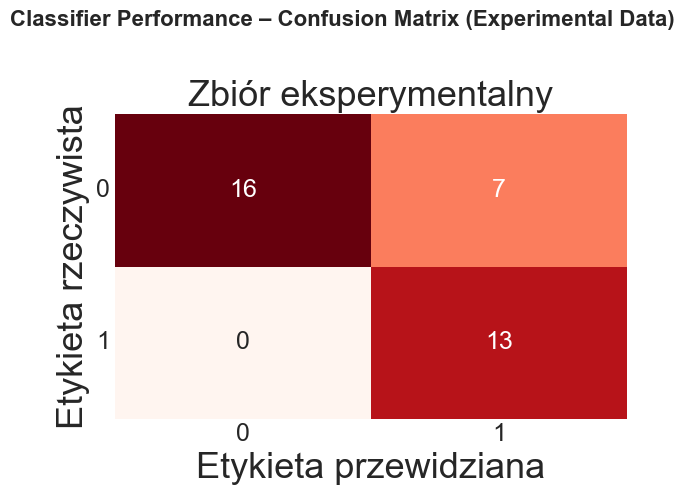

In [90]:
plt.style.use('seaborn-v0_8-whitegrid')

# Class labels (sorted for consistent ordering)
labels = np.sort(train_df[TARGET_COLUMN].unique())

# --- Test (Experimental) Confusion Matrix ---
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle('Classifier Performance – Confusion Matrix (Experimental Data)', fontsize=16, fontweight='bold')

cm_test = confusion_matrix(data['epox_cla'], y_pred_exp, labels=labels)
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Reds',
    cbar=False,
    ax=ax,
    annot_kws={"size": 18}   # larger numbers inside cells
)

ax.set_title('Zbiór eksperymentalny', fontsize=26)
ax.set_xlabel('Etykieta przewidziana', fontsize=26)
ax.set_ylabel('Etykieta rzeczywista', fontsize=26)

# Larger tick labels (x and y)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.set_xticklabels(labels)
ax.set_yticklabels(labels, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# Save confusion-matrix figure
plt.savefig('classifier_confusion_matrix_exp_DOKTORAT.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()